In [1]:
# conda activate hb_diff_loss
import face_alignment
from skimage import io

/home/cvlab20/anaconda3/envs/hb_diff_loss/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
fa = face_alignment.FaceAlignment(face_alignment.LandmarksType.TWO_D, flip_input=False)



Downloading: "https://www.adrianbulat.com/downloads/python-fan/s3fd-619a316812.pth" to /home/cvlab20/.cache/torch/hub/checkpoints/s3fd-619a316812.pth


100%|██████████| 85.7M/85.7M [00:26<00:00, 3.43MB/s]
Downloading: "https://www.adrianbulat.com/downloads/python-fan/2DFAN4-cd938726ad.zip" to /home/cvlab20/.cache/torch/hub/checkpoints/2DFAN4-cd938726ad.zip
100%|██████████| 91.9M/91.9M [00:14<00:00, 6.51MB/s]


In [9]:
input = io.imread('/mnt/dataset1/jinhyuk/Hallo3/cropped_only_10K_preprocessed/images/00a1a33234d719b5a54a31fec84117ff/frame_000001.jpg')
preds = fa.get_landmarks(input)[-1]

(np.float64(-0.5), np.float64(831.5), np.float64(479.5), np.float64(-0.5))

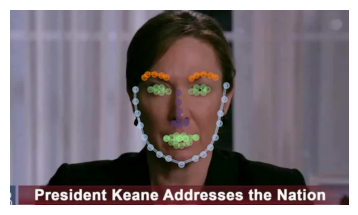

In [10]:
import collections
import matplotlib.pyplot as plt
# 2D-Plot
plot_style = dict(marker='o',
                  markersize=4,
                  linestyle='-',
                  lw=2)

pred_type = collections.namedtuple('prediction_type', ['slice', 'color'])
pred_types = {'face': pred_type(slice(0, 17), (0.682, 0.780, 0.909, 0.5)),
              'eyebrow1': pred_type(slice(17, 22), (1.0, 0.498, 0.055, 0.4)),
              'eyebrow2': pred_type(slice(22, 27), (1.0, 0.498, 0.055, 0.4)),
              'nose': pred_type(slice(27, 31), (0.345, 0.239, 0.443, 0.4)),
              'nostril': pred_type(slice(31, 36), (0.345, 0.239, 0.443, 0.4)),
              'eye1': pred_type(slice(36, 42), (0.596, 0.875, 0.541, 0.3)),
              'eye2': pred_type(slice(42, 48), (0.596, 0.875, 0.541, 0.3)),
              'lips': pred_type(slice(48, 60), (0.596, 0.875, 0.541, 0.3)),
              'teeth': pred_type(slice(60, 68), (0.596, 0.875, 0.541, 0.4))
              }

fig = plt.figure(figsize=plt.figaspect(.5))
ax = fig.add_subplot(1, 2, 1)
ax.imshow(input)

for pred_type in pred_types.values():
    ax.plot(preds[pred_type.slice, 0],
            preds[pred_type.slice, 1],
            color=pred_type.color, **plot_style)

ax.axis('off')

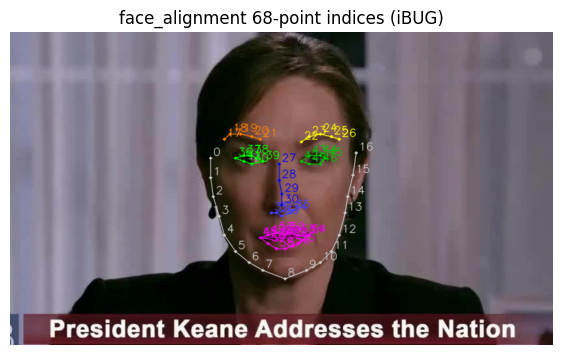

jaw: 0..16 (17)
right_eyebrow: 17..21 (5)
left_eyebrow: 22..26 (5)
nose_bridge: 27..30 (4)
nose_lower: 31..35 (5)
right_eye: 36..41 (6)
left_eye: 42..47 (6)
outer_lip: 48..59 (12)
inner_lip: 60..67 (8)


In [12]:
# Visualize face_alignment 68-pt indices on the current image
import matplotlib.pyplot as plt
from landmark_viz import (
    overlay_landmark_indices_rgb,
    get_68_indices_by_region,
)

# Use the image and landmarks you already computed
img_rgb = input          # from io.imread(...)
landmarks = preds        # from fa.get_landmarks(...)[-1] or selected face

viz = overlay_landmark_indices_rgb(
    img_rgb,
    landmarks,
    draw_connections=True,
    put_indices=True,
)

plt.figure(figsize=(7,7))
plt.imshow(viz)
plt.axis('off')
plt.title('face_alignment 68-point indices (iBUG)')
plt.show()

# Print region → index ranges for quick reference
region_map = get_68_indices_by_region()
for k, v in region_map.items():
    print(f"{k}: {v[0]}..{v[-1]} ({len(v)})")


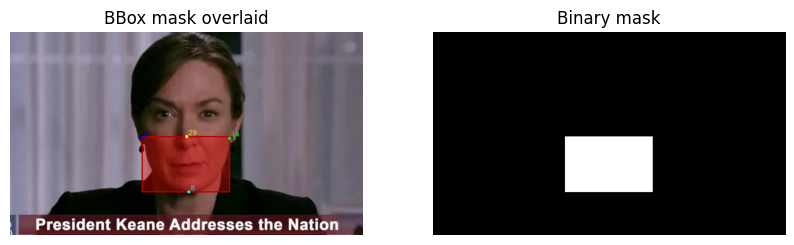

bbox (x_left, y_top, x_right, y_bottom): 311 248 517 378


In [13]:
# BBox mask from jaw[2], jaw[14] (width) and nose_bridge[29], jaw[8] (height)
import numpy as np, cv2, matplotlib.pyplot as plt

img_rgb = input          # from skimage.io.imread(...)
pts = np.asarray(preds)
if pts.ndim == 3:
    pts = pts[0]
xy = pts[:, :2]

# Anchor indices
x2, y2   = xy[2]
x14, y14 = xy[14]
x29, y29 = xy[29]
x8, y8   = xy[8]

# Compute bbox (clipped to image)
x_left   = int(np.floor(min(x2, x14)))
x_right  = int(np.ceil(max(x2, x14)))
y_top    = int(np.floor(min(y29, y8)))   # y increases downward
y_bottom = int(np.ceil(max(y29, y8)))

h, w = img_rgb.shape[:2]
x_left   = int(np.clip(x_left, 0, w - 1))
x_right  = int(np.clip(x_right, 0, w - 1))
y_top    = int(np.clip(y_top, 0, h - 1))
y_bottom = int(np.clip(y_bottom, 0, h - 1))

# Binary mask
mask = np.zeros((h, w), dtype=np.uint8)
mask[y_top:y_bottom + 1, x_left:x_right + 1] = 255

# Prepare image for drawing
img8 = img_rgb
if img8.dtype != np.uint8:
    img8 = np.clip(img8, 0, 255)
    img8 = (img8 * 255).round().astype(np.uint8) if img8.max() <= 1.0 else img8.round().astype(np.uint8)

bgr = cv2.cvtColor(img8, cv2.COLOR_RGB2BGR)

# Filled overlay + border
overlay = bgr.copy()
cv2.rectangle(overlay, (x_left, y_top), (x_right, y_bottom), (0, 0, 255), thickness=-1)
alpha = 0.35
blended = cv2.addWeighted(overlay, alpha, bgr, 1 - alpha, 0)
cv2.rectangle(blended, (x_left, y_top), (x_right, y_bottom), (0, 0, 180), thickness=2)

# Mark anchor points
anchors = {2: (255, 0, 0), 14: (0, 255, 0), 29: (0, 255, 255), 8: (255, 255, 0)}  # BGR
for idx, color in anchors.items():
    x, y = xy[idx]
    p = (int(round(x)), int(round(y)))
    cv2.circle(blended, p, 3, color, -1, lineType=cv2.LINE_AA)
    cv2.putText(blended, str(idx), (p[0] + 4, p[1] - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, lineType=cv2.LINE_AA)

viz_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

# Show overlay and binary mask
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(viz_rgb); ax[0].set_title("BBox mask overlaid"); ax[0].axis("off")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("Binary mask"); ax[1].axis("off")
plt.show()

print("bbox (x_left, y_top, x_right, y_bottom):", x_left, y_top, x_right, y_bottom)


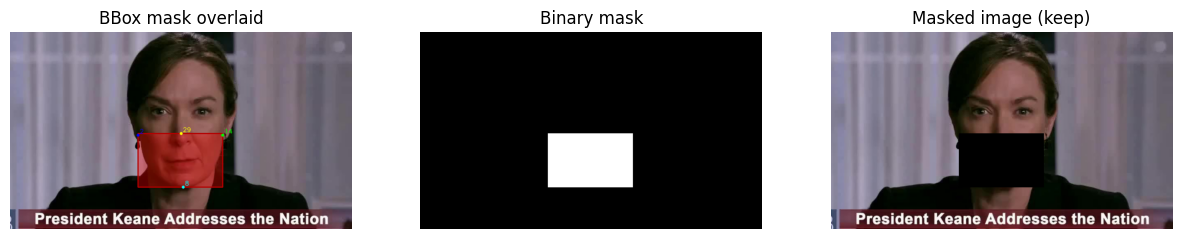

bbox (x_left, y_top, x_right, y_bottom): 311 248 517 378


In [15]:
# BBox mask + overlay + masked image (keep only the bbox region)
import numpy as np, cv2, matplotlib.pyplot as plt

img_rgb = input          # from skimage.io.imread(...)
pts = np.asarray(preds)
if pts.ndim == 3:
    pts = pts[0]
xy = pts[:, :2]

# Anchor indices
x2, y2   = xy[2]
x14, y14 = xy[14]
x29, y29 = xy[29]
x8, y8   = xy[8]

# Compute bbox (clipped to image)
h, w = img_rgb.shape[:2]
x_left   = int(np.clip(np.floor(min(x2, x14)), 0, w - 1))
x_right  = int(np.clip(np.ceil(max(x2, x14)), 0, w - 1))
y_top    = int(np.clip(np.floor(min(y29, y8)), 0, h - 1))   # y increases downward
y_bottom = int(np.clip(np.ceil(max(y29, y8)), 0, h - 1))

# Binary mask (uint8, 0/255)
mask = np.zeros((h, w), dtype=np.uint8)
mask[y_top:y_bottom + 1, x_left:x_right + 1] = 255

# Ensure uint8 image for OpenCV ops
img8_rgb = img_rgb
if img8_rgb.dtype != np.uint8:
    tmp = img8_rgb.astype(np.float32)
    if tmp.max() <= 1.0: tmp *= 255.0
    img8_rgb = np.clip(tmp, 0, 255).round().astype(np.uint8)

# 1) Overlay (filled + border + anchors)
bgr = cv2.cvtColor(img8_rgb, cv2.COLOR_RGB2BGR)
overlay = bgr.copy()
cv2.rectangle(overlay, (x_left, y_top), (x_right, y_bottom), (0, 0, 255), thickness=-1)
alpha = 0.35
blended = cv2.addWeighted(overlay, alpha, bgr, 1 - alpha, 0)
cv2.rectangle(blended, (x_left, y_top), (x_right, y_bottom), (0, 0, 180), thickness=2)
anchors = {2: (255, 0, 0), 14: (0, 255, 0), 29: (0, 255, 255), 8: (255, 255, 0)}  # BGR
for idx, color in anchors.items():
    x, y = xy[idx]
    p = (int(round(x)), int(round(y)))
    cv2.circle(blended, p, 3, color, -1, lineType=cv2.LINE_AA)
    cv2.putText(blended, str(idx), (p[0] + 4, p[1] - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1, lineType=cv2.LINE_AA)
viz_rgb = cv2.cvtColor(blended, cv2.COLOR_BGR2RGB)

# 2) Binary mask is already prepared as `mask`

# 3) Masked image (keep only bbox region)
masked_out_rgb = cv2.bitwise_and(img8_rgb, img8_rgb, mask=cv2.bitwise_not(mask))
# Show all three
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(viz_rgb);           ax[0].set_title("BBox mask overlaid"); ax[0].axis("off")
ax[1].imshow(mask, cmap="gray"); ax[1].set_title("Binary mask");       ax[1].axis("off")
ax[2].imshow(masked_out_rgb);   ax[2].set_title("Masked image (keep)"); ax[2].axis("off")
plt.show()

print("bbox (x_left, y_top, x_right, y_bottom):", x_left, y_top, x_right, y_bottom)


In [16]:
fa_3d = face_alignment.FaceAlignment(face_alignment.LandmarksType.THREE_D, flip_input=False, device='cuda')



Downloading: "https://www.adrianbulat.com/downloads/python-fan/3DFAN4-4a694010b9.zip" to /home/cvlab20/.cache/torch/hub/checkpoints/3DFAN4-4a694010b9.zip
100%|██████████| 91.9M/91.9M [00:16<00:00, 5.83MB/s]
Downloading: "https://www.adrianbulat.com/downloads/python-fan/depth-6c4283c0e0.zip" to /home/cvlab20/.cache/torch/hub/checkpoints/depth-6c4283c0e0.zip
100%|██████████| 224M/224M [01:02<00:00, 3.77MB/s] 


In [17]:
preds = fa.get_landmarks_from_directory('/mnt/dataset1/jinhyuk/Hallo3/cropped_only_10K_preprocessed/images/00a1a33234d719b5a54a31fec84117ff/')

100%|██████████| 140/140 [00:05<00:00, 27.48it/s]


In [18]:
len(preds)

140

In [23]:
# Save a "mask-out" MP4: zero inside bbox, keep rest unchanged
from pathlib import Path
import numpy as np, cv2, glob, torch
from torchvision.io import write_video

try:
    import av
except Exception:
    av = None

def _normalize_pred_map(preds_dir_dict):
    """
    Return {abs_img_path: (68,2)} with last face per image, x,y only.
    Accepts the dict returned by fa.get_landmarks_from_directory(...).
    """
    out = {}
    for k, v in preds_dir_dict.items():
        key_abs = str(Path(k).resolve())
        lm = None
        if isinstance(v, (list, tuple)):
            if len(v) == 0:
                continue
            lm = np.asarray(v[-1])  # last detected face
        else:
            lm = np.asarray(v)
        if lm.ndim == 3:
            lm = lm[0]
        out[key_abs] = lm[..., :2]
    return out

def _bbox_from_landmarks(xy, h, w, margin=0):
    x2,  y2  = xy[2]
    x14, y14 = xy[14]
    x29, y29 = xy[29]
    x8,  y8  = xy[8]
    x_left   = int(np.floor(min(x2, x14))) - margin
    x_right  = int(np.ceil(max(x2, x14)))  + margin
    y_top    = int(np.floor(min(y29, y8))) - margin   # y grows downward
    y_bottom = int(np.ceil(max(y29, y8)))  + margin
    x_left   = int(np.clip(x_left,   0, w - 1))
    x_right  = int(np.clip(x_right,  0, w - 1))
    y_top    = int(np.clip(y_top,    0, h - 1))
    y_bottom = int(np.clip(y_bottom, 0, h - 1))
    if x_right < x_left: x_left, x_right = x_right, x_left
    if y_bottom < y_top: y_top, y_bottom = y_bottom, y_top
    return x_left, y_top, x_right, y_bottom

def _write_pyav(frames_rgb_uint8, fps, out_path):
    H, W = frames_rgb_uint8[0].shape[:2]
    container = av.open(str(out_path), mode='w')
    try:
        vstream = container.add_stream('libx264', rate=int(fps))
        vstream.width = W
        vstream.height = H
        vstream.pix_fmt = 'yuv420p'
        for fr in frames_rgb_uint8:
            frame = av.VideoFrame.from_ndarray(fr, format='rgb24')
            for pkt in vstream.encode(frame):
                container.mux(pkt)
        for pkt in vstream.encode():
            container.mux(pkt)
    finally:
        container.close()

def _write_torchvision(frames_rgb_uint8, fps, out_path):
    t = torch.from_numpy(np.stack(frames_rgb_uint8, axis=0))  # [T,H,W,3], uint8
    write_video(str(out_path), t, fps=int(fps), video_codec='h264', options={"crf": "18"})

def make_mask_out_video(frames_dir, preds_dir_dict, fps=25, margin=0):
    frames_dir = Path(frames_dir)
    video_id = frames_dir.name
    out_path = Path(".") / f"mask_out_{video_id}.mp4"

    # Frame list in order
    exts = ("*.jpg", "*.jpeg", "*.png")
    frame_files = []
    for ext in exts:
        frame_files.extend(glob.glob(str(frames_dir / ext)))
    frame_files = sorted(frame_files)
    if not frame_files:
        raise FileNotFoundError(f"No frames found in {frames_dir}")

    pred_map = _normalize_pred_map(preds_dir_dict)

    frames_rgb = []
    missing = 0
    for f in frame_files:
        img_bgr = cv2.imread(f, cv2.IMREAD_COLOR)
        if img_bgr is None:
            continue
        H, W = img_bgr.shape[:2]

        xy = pred_map.get(str(Path(f).resolve()))
        if xy is None or len(xy) < 68:
            # No landmarks → keep original frame
            frames_rgb.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
            missing += 1
            continue

        x_left, y_top, x_right, y_bottom = _bbox_from_landmarks(xy, H, W, margin=margin)
        mask = np.zeros((H, W), dtype=np.uint8)
        mask[y_top:y_bottom + 1, x_left:x_right + 1] = 255

        # Mask-out: zero inside bbox, keep outside unchanged
        out_bgr = cv2.bitwise_and(img_bgr, img_bgr, mask=cv2.bitwise_not(mask))
        frames_rgb.append(cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB))

    # Write with PyAV if available, else torchvision
    if av is not None:
        _write_pyav(frames_rgb, fps=fps, out_path=out_path)
    else:
        _write_torchvision(frames_rgb, fps=fps, out_path=out_path)

    print(f"Saved: {out_path}")
    if missing:
        print(f"Note: {missing} frames had no landmarks; original frames kept at those timestamps.")

# Usage
frames_dir = "/mnt/dataset1/jinhyuk/Hallo3/cropped_only_10K_preprocessed/images/00a1a33234d719b5a54a31fec84117ff"
# preds should be from:
# preds = fa.get_landmarks_from_directory(frames_dir)
make_mask_out_video(frames_dir, preds, fps=25, margin=0)


Saved: mask_out_00a1a33234d719b5a54a31fec84117ff.mp4


In [24]:
# Mask-out video with temporal smoothing of landmarks (alpha = 0.75)
from pathlib import Path
import numpy as np, cv2, glob, torch
from torchvision.io import write_video
from tqdm.auto import tqdm
try:
    import av
except Exception:
    av = None

def _normalize_pred_map(preds_dir_dict):
    out = {}
    for k, v in preds_dir_dict.items():
        key_abs = str(Path(k).resolve())
        lm = np.asarray(v[-1]) if isinstance(v, (list, tuple)) and len(v) > 0 else np.asarray(v)
        if lm.ndim == 3:  # (F,68,2/3)
            lm = lm[0]
        out[key_abs] = lm[..., :2]
    return out

def _bbox_from_landmarks(xy, h, w, margin=0):
    x2,  y2  = xy[2]
    x14, y14 = xy[14]
    x29, y29 = xy[29]
    x8,  y8  = xy[8]
    x_left   = int(np.floor(min(x2, x14))) - margin
    x_right  = int(np.ceil(max(x2, x14)))  + margin
    y_top    = int(np.floor(min(y29, y8))) - margin
    y_bottom = int(np.ceil(max(y29, y8)))  + margin
    x_left   = int(np.clip(x_left,   0, w - 1))
    x_right  = int(np.clip(x_right,  0, w - 1))
    y_top    = int(np.clip(y_top,    0, h - 1))
    y_bottom = int(np.clip(y_bottom, 0, h - 1))
    if x_right < x_left: x_left, x_right = x_right, x_left
    if y_bottom < y_top: y_top, y_bottom = y_bottom, y_top
    return x_left, y_top, x_right, y_bottom

def _write_pyav(frames_rgb_uint8, fps, out_path):
    H, W = frames_rgb_uint8[0].shape[:2]
    container = av.open(str(out_path), mode='w')
    try:
        vstream = container.add_stream('libx264', rate=int(fps))
        vstream.width = W; vstream.height = H; vstream.pix_fmt = 'yuv420p'
        for fr in frames_rgb_uint8:
            frame = av.VideoFrame.from_ndarray(fr, format='rgb24')
            for pkt in vstream.encode(frame):
                container.mux(pkt)
        for pkt in vstream.encode():
            container.mux(pkt)
    finally:
        container.close()

def _write_torchvision(frames_rgb_uint8, fps, out_path):
    t = torch.from_numpy(np.stack(frames_rgb_uint8, axis=0))  # [T,H,W,3], uint8
    write_video(str(out_path), t, fps=int(fps), video_codec='h264', options={"crf": "18"})

def make_mask_video_temporal(frames_dir, preds_dir_dict, fps=25, margin=0, mode="out", alpha=0.75):
    """
    mode: 'out' (zero inside bbox) or 'keep' (keep only bbox)
    alpha: temporal smoothing factor applied as x'_t = a*x_t + (1-a)*x_{t+1}
    """
    frames_dir = Path(frames_dir)
    video_id = frames_dir.name
    out_path = Path(".") / f"mask_{mode}_{video_id}_a{alpha}.mp4"

    # Ordered frame list
    exts = ("*.jpg", "*.jpeg", "*.png")
    frame_files = sorted([f for ext in exts for f in glob.glob(str(frames_dir / ext))])
    if not frame_files:
        raise FileNotFoundError(f"No frames found in {frames_dir}")
    frame_abs = [str(Path(f).resolve()) for f in frame_files]

    # Landmarks map and aligned list
    pred_map = _normalize_pred_map(preds_dir_dict)
    xy_list = [pred_map.get(p, None) for p in frame_abs]

    # Forward smoothing
    a = float(alpha)
    xy_smooth = []
    for i in range(len(xy_list)):
        cur = xy_list[i]
        nxt = xy_list[i + 1] if i + 1 < len(xy_list) else None
        if cur is not None and nxt is not None:
            xy_smooth.append(a * cur + (1.0 - a) * nxt)
        else:
            xy_smooth.append(cur)  # fallback

    # Build frames
    frames_rgb = []
    missing = 0
    for i, f in enumerate(tqdm(frame_files, desc=f"mask_{mode}_{video_id}_a{alpha}")):
        img_bgr = cv2.imread(f, cv2.IMREAD_COLOR)
        if img_bgr is None:
            continue
        H, W = img_bgr.shape[:2]
        xy = xy_smooth[i]

        if xy is None or len(xy) < 68:
            frames_rgb.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
            missing += 1
            continue

        x_left, y_top, x_right, y_bottom = _bbox_from_landmarks(xy, H, W, margin=margin)
        mask = np.zeros((H, W), dtype=np.uint8)
        mask[y_top:y_bottom + 1, x_left:x_right + 1] = 255

        if mode == "out":
            out_bgr = cv2.bitwise_and(img_bgr, img_bgr, mask=cv2.bitwise_not(mask))
        elif mode == "keep":
            out_bgr = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
        else:
            raise ValueError("mode must be 'out' or 'keep'")

        frames_rgb.append(cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB))

    # Write video
    if av is not None:
        _write_pyav(frames_rgb, fps=fps, out_path=out_path)
    else:
        _write_torchvision(frames_rgb, fps=fps, out_path=out_path)

    print(f"Saved: {out_path}")
    if missing:
        print(f"Note: {missing} frames had no landmarks; original frames kept at those timestamps.")

# Usage (same frames_dir you used for get_landmarks_from_directory)
frames_dir = "/mnt/dataset1/jinhyuk/Hallo3/cropped_only_10K_preprocessed/images/00a1a33234d719b5a54a31fec84117ff"
# preds = fa.get_landmarks_from_directory(frames_dir)
make_mask_video_temporal(frames_dir, preds, fps=25, margin=0, mode="out", alpha=0.75)


mask_out_00a1a33234d719b5a54a31fec84117ff_a0.75: 100%|██████████| 140/140 [00:00<00:00, 344.26it/s]


Saved: mask_out_00a1a33234d719b5a54a31fec84117ff_a0.75.mp4


In [26]:
# Mask video with temporal smoothing (alpha=0.75) and proportional bbox expansion (scale=0.1)
from pathlib import Path
import numpy as np, cv2, glob, torch
from torchvision.io import write_video
from tqdm.auto import tqdm
try:
    import av
except Exception:
    av = None

def _normalize_pred_map(preds_dir_dict):
    out = {}
    for k, v in preds_dir_dict.items():
        key_abs = str(Path(k).resolve())
        lm = np.asarray(v[-1]) if isinstance(v, (list, tuple)) and len(v) > 0 else np.asarray(v)
        if lm.ndim == 3:  # (F,68,2/3) -> take first
            lm = lm[0]
        out[key_abs] = lm[..., :2]
    return out

def _bbox_from_landmarks(xy):
    # Base box from indices: width via jaw[2], jaw[14]; height via nose_bridge[29], jaw[8]
    x2,  y2  = xy[2]
    x14, y14 = xy[14]
    x29, y29 = xy[29]
    x8,  y8  = xy[8]
    x_left   = float(min(x2, x14))
    x_right  = float(max(x2, x14))
    y_top    = float(min(y29, y8))   # y increases downward
    y_bottom = float(max(y29, y8))
    return x_left, y_top, x_right, y_bottom

def _scale_bbox_centered(x_left, y_top, x_right, y_bottom, scale, H, W):
    # Centered scale by (1+scale) in both width and height, then clip to image.
    cx = 0.5 * (x_left + x_right)
    cy = 0.5 * (y_top + y_bottom)
    w0 = (x_right - x_left + 1.0)
    h0 = (y_bottom - y_top + 1.0)
    w1 = w0 * (1.0 + scale)
    h1 = h0 * (1.0 + scale)
    nx_left   = int(np.floor(cx - 0.5 * w1))
    nx_right  = int(np.ceil (cx + 0.5 * w1) - 1)
    ny_top    = int(np.floor(cy - 0.5 * h1))
    ny_bottom = int(np.ceil (cy + 0.5 * h1) - 1)
    # Clip
    nx_left   = int(np.clip(nx_left,   0, W - 1))
    nx_right  = int(np.clip(nx_right,  0, W - 1))
    ny_top    = int(np.clip(ny_top,    0, H - 1))
    ny_bottom = int(np.clip(ny_bottom, 0, H - 1))
    if nx_right < nx_left:   nx_left, nx_right   = nx_right, nx_left
    if ny_bottom < ny_top:   ny_top,  ny_bottom  = ny_bottom, ny_top
    return nx_left, ny_top, nx_right, ny_bottom

def _write_pyav(frames_rgb_uint8, fps, out_path):
    H, W = frames_rgb_uint8[0].shape[:2]
    container = av.open(str(out_path), mode='w')
    try:
        vstream = container.add_stream('libx264', rate=int(fps))
        vstream.width = W; vstream.height = H; vstream.pix_fmt = 'yuv420p'
        for fr in frames_rgb_uint8:
            frame = av.VideoFrame.from_ndarray(fr, format='rgb24')
            for pkt in vstream.encode(frame): container.mux(pkt)
        for pkt in vstream.encode(): container.mux(pkt)
    finally:
        container.close()

def _write_torchvision(frames_rgb_uint8, fps, out_path):
    t = torch.from_numpy(np.stack(frames_rgb_uint8, axis=0))  # [T,H,W,3], uint8
    write_video(str(out_path), t, fps=int(fps), video_codec='h264', options={"crf": "18"})

def make_mask_video_temporal(
    frames_dir, preds_dir_dict, fps=25,
    mode="out", alpha=0.75, scale=0.10, save_dir=None
):
    """
    mode: 'out' (zero inside bbox) or 'keep' (keep only bbox).
    alpha: forward smoothing: x'_t = a*x_t + (1-a)*x_{t+1}.
    scale: proportional expansion (e.g., 0.10 = +10%) applied to bbox, centered.
    save_dir: optional output directory (defaults to frames_dir).
    """
    frames_dir = Path(frames_dir)
    video_id = frames_dir.name
    out_root = Path(save_dir) if save_dir else frames_dir
    out_path = out_root / f"mask_{mode}_{video_id}_a{alpha}_s{scale}.mp4"

    # Ordered frames
    exts = ("*.jpg", "*.jpeg", "*.png")
    frame_files = sorted([f for ext in exts for f in glob.glob(str(frames_dir / ext))])
    if not frame_files:
        raise FileNotFoundError(f"No frames found in {frames_dir}")
    frame_abs = [str(Path(f).resolve()) for f in frame_files]

    pred_map = _normalize_pred_map(preds_dir_dict)
    xy = [pred_map.get(p, None) for p in frame_abs]

    # Forward temporal smoothing
    a = float(alpha)
    xys = []
    for i in range(len(xy)):
        cur = xy[i]
        nxt = xy[i + 1] if i + 1 < len(xy) else None
        xys.append(a * cur + (1.0 - a) * nxt if (cur is not None and nxt is not None) else cur)

    frames_rgb = []
    missing = 0
    for i, f in enumerate(tqdm(frame_files, desc=out_path.name)):
        img_bgr = cv2.imread(f, cv2.IMREAD_COLOR)
        if img_bgr is None: continue
        H, W = img_bgr.shape[:2]
        pts = xys[i]

        if pts is None or len(pts) < 68:
            frames_rgb.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
            missing += 1
            continue

        # Base bbox from landmarks, then centered proportional expansion
        xl, yt, xr, yb = _bbox_from_landmarks(pts)
        x_left, y_top, x_right, y_bottom = _scale_bbox_centered(xl, yt, xr, yb, scale=scale, H=H, W=W)

        mask = np.zeros((H, W), dtype=np.uint8)
        mask[y_top:y_bottom + 1, x_left:x_right + 1] = 255

        if mode == "out":
            out_bgr = cv2.bitwise_and(img_bgr, img_bgr, mask=cv2.bitwise_not(mask))
        elif mode == "keep":
            out_bgr = cv2.bitwise_and(img_bgr, img_bgr, mask=mask)
        else:
            raise ValueError("mode must be 'out' or 'keep'")

        frames_rgb.append(cv2.cvtColor(out_bgr, cv2.COLOR_BGR2RGB))

    if av is not None:
        _write_pyav(frames_rgb, fps=fps, out_path=out_path)
    else:
        _write_torchvision(frames_rgb, fps=fps, out_path=out_path)

    print(f"Saved: {out_path}")
    if missing:
        print(f"Note: {missing} frames had no landmarks; original frames kept at those timestamps.")

# Usage
frames_dir = "/mnt/dataset1/jinhyuk/Hallo3/cropped_only_10K_preprocessed/images/00a1a33234d719b5a54a31fec84117ff"
# preds = fa.get_landmarks_from_directory(frames_dir)
make_mask_video_temporal(frames_dir, preds, fps=25, mode="out", alpha=0.75, scale=0.10, save_dir=".")


mask_out_00a1a33234d719b5a54a31fec84117ff_a0.75_s0.1.mp4: 100%|██████████| 140/140 [00:00<00:00, 336.17it/s]


Saved: mask_out_00a1a33234d719b5a54a31fec84117ff_a0.75_s0.1.mp4
